# Math Requirements for Molecule Analysis

This notebook turns the math plan into a concrete learning map tied to the datasets in `data/`.

Covered topics:
- Algebra
- Linear Algebra
- Calculus
- Multivariable Calculus
- Statistics

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))

delaney = pd.read_csv(DATA_DIR / "delaney-processed.csv")
bbbp = pd.read_csv(DATA_DIR / "BBBP.csv")

numeric_features = [
    "ESOL predicted log solubility in mols per litre",
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
target = "measured log solubility in mols per litre"

print("Delaney shape:", delaney.shape)
print("BBBP shape:", bbbp.shape)

Delaney shape: (1128, 10)
BBBP shape: (2050, 4)


## 1. Algebra

Core requirements:
- linear and affine functions
- logarithms and exponentials
- ratios and rates
- systems of equations
- threshold-based decision rules

Why this matters here:
- property targets like solubility are often already log-scaled
- linear models combine weighted feature sums
- binary classification turns continuous scores into thresholded decisions

In [23]:
algebra_demo = delaney[
    [
        "Molecular Weight",
        "Number of Rotatable Bonds",
        target,
    ]
].copy()
algebra_demo["simple_linear_score"] = (
    -0.01 * algebra_demo["Molecular Weight"]
    - 0.20 * algebra_demo["Number of Rotatable Bonds"]
    + 1.0
)
algebra_demo["predicted_soluble"] = (algebra_demo["simple_linear_score"] > -2.0).astype(
    int
)
display(algebra_demo.head(10))

,Molecular Weight,Number of Rotatable Bonds,measured log solubility in mols per litre,simple_linear_score,predicted_soluble
0,457.432,7,-0.77,-4.97432,0
1,201.225,2,-3.30,-1.41225,1
2,152.237,4,-2.06,-1.32237,1
3,278.354,0,-7.87,-1.78354,1
4,84.143,0,-1.33,0.15857,1
5,135.191,0,-1.50,-0.35191,1
6,326.437,1,-7.32,-2.46437,0
7,272.388,0,-5.03,-1.72388,1
8,380.913,0,-6.29,-2.80913,0
9,394.423,3,-4.42,-3.54423,0


## 2. Linear Algebra

Core requirements:
- vectors and matrices
- matrix multiplication
- dot products and projections
- covariance matrices
- eigenvalues and eigenvectors
- PCA intuition

Why this matters here:
- descriptor tables are feature matrices
- model training is mostly vectorized matrix algebra
- dimensionality reduction is useful for wide molecular descriptors

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area
ESOL predicted log solubility in mols per litre,1.001,-0.110,-0.681,0.282,-0.497,-0.250,0.189
Minimum Degree,-0.110,1.001,-0.097,-0.131,0.246,-0.176,-0.190
Molecular Weight,-0.681,-0.097,1.001,0.255,0.653,0.397,0.476
Number of H-Bond Donors,0.282,-0.131,0.255,1.001,0.211,0.077,0.757
Number of Rings,-0.497,0.246,0.653,0.211,1.001,-0.137,0.309
Number of Rotatable Bonds,-0.250,-0.176,0.397,0.077,-0.137,1.001,0.287
Polar Surface Area,0.189,-0.190,0.476,0.757,0.309,0.287,1.001


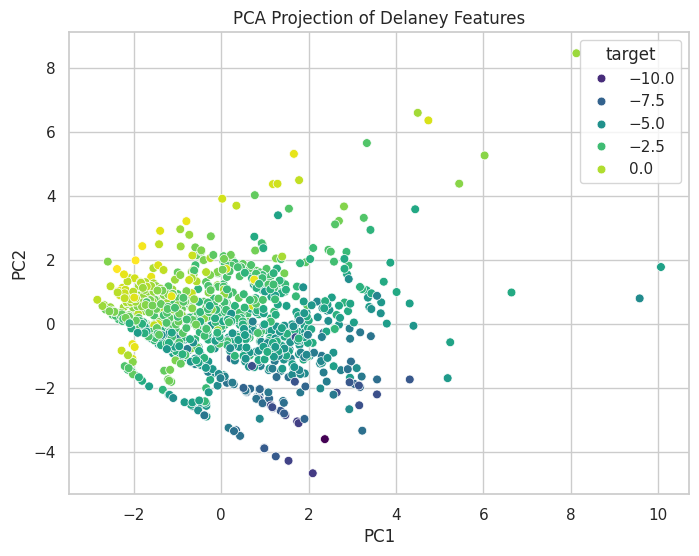

Explained variance ratio: [0.36606082 0.26890173]


In [24]:
X = delaney[numeric_features].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
covariance = np.cov(X_scaled, rowvar=False)
covariance_df = pd.DataFrame(
    covariance, index=numeric_features, columns=numeric_features
)
display(covariance_df.round(3))

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    {"PC1": components[:, 0], "PC2": components[:, 1], "target": delaney[target]}
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target", palette="viridis", s=40)
plt.title("PCA Projection of Delaney Features")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## 3. Calculus

Core requirements:
- derivatives
- slope and local sensitivity
- chain rule
- optimization of loss functions
- gradient descent intuition

Why this matters here:
- training minimizes a loss
- model parameters move in the direction of negative gradients

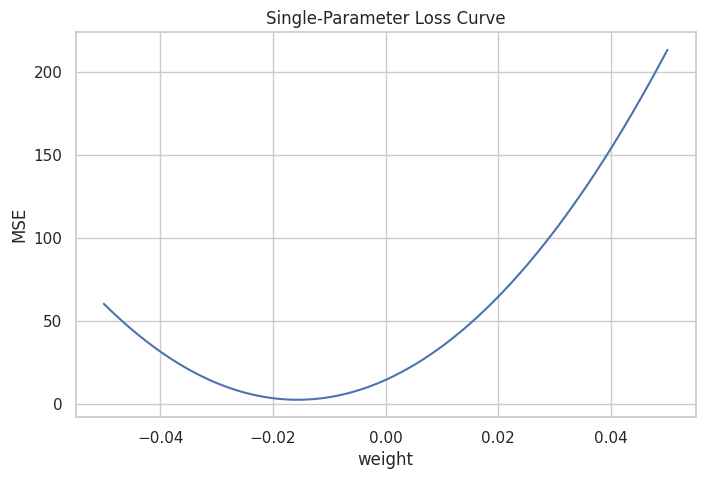

In [25]:
x = delaney["Molecular Weight"].to_numpy()[:200]
y = delaney[target].to_numpy()[:200]


def mse_for_weight(weight: float) -> float:
    predictions = weight * x
    return float(np.mean((predictions - y) ** 2))


weights = np.linspace(-0.05, 0.05, 200)
losses = np.array([mse_for_weight(weight) for weight in weights])

plt.figure(figsize=(8, 5))
plt.plot(weights, losses)
plt.title("Single-Parameter Loss Curve")
plt.xlabel("weight")
plt.ylabel("MSE")
plt.show()

## 4. Multivariable Calculus

Core requirements:
- gradients
- partial derivatives
- Jacobian and Hessian intuition
- multi-parameter optimization

Why this matters here:
- realistic models have many parameters
- multi-task models optimize a shared parameter surface

In [26]:
subset = (
    delaney[["Molecular Weight", "Polar Surface Area", target]]
    .dropna()
    .head(200)
    .copy()
)
X_small = subset[["Molecular Weight", "Polar Surface Area"]].to_numpy()
y_small = subset[target].to_numpy()

weights = np.zeros(2)
bias = 0.0

pred = X_small @ weights + bias
error = pred - y_small
grad_w = (2 / len(X_small)) * X_small.T @ error
grad_b = float((2 / len(X_small)) * error.sum())

print("Gradient with respect to weights:", grad_w)
print("Gradient with respect to bias:", grad_b)

Gradient with respect to weights: [1530.13598607  184.7957065 ]
Gradient with respect to bias: 6.2233600000000004


## 5. Statistics

Core requirements:
- descriptive statistics
- distributions
- correlation and covariance
- class balance
- sampling and splits
- confidence intervals and uncertainty
- evaluation metrics

Why this matters here:
- small clean datasets and sparse multi-task datasets behave very differently
- bad splits or ignored imbalance can make results misleading

,count,mean,std,min,25%,50%,75%,max
ESOL predicted log solubility in mols per litre,1128.0,-2.988192,1.683220,-9.702,-3.94825,-2.870,-1.84375,1.091
Minimum Degree,1128.0,1.058511,0.238560,0.000,1.00000,1.000,1.00000,2.000
Molecular Weight,1128.0,203.937074,102.738077,16.043,121.18300,182.179,270.37200,780.949
Number of H-Bond Donors,1128.0,0.701241,1.089727,0.000,0.00000,0.000,1.00000,11.000
Number of Rings,1128.0,1.390957,1.318286,0.000,0.00000,1.000,2.00000,8.000
Number of Rotatable Bonds,1128.0,2.177305,2.640974,0.000,0.00000,1.000,3.00000,23.000
Polar Surface Area,1128.0,34.872881,35.383593,0.000,0.00000,26.300,55.44000,268.680
measured log solubility in mols per litre,1128.0,-3.050102,2.096441,-11.600,-4.31750,-2.860,-1.60000,1.580


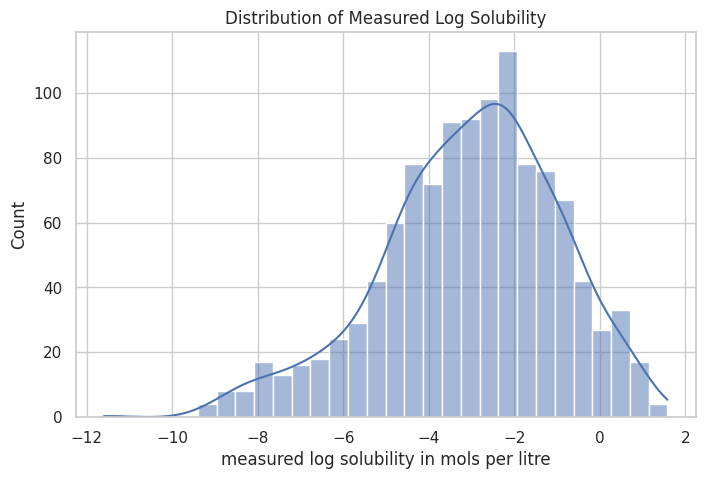

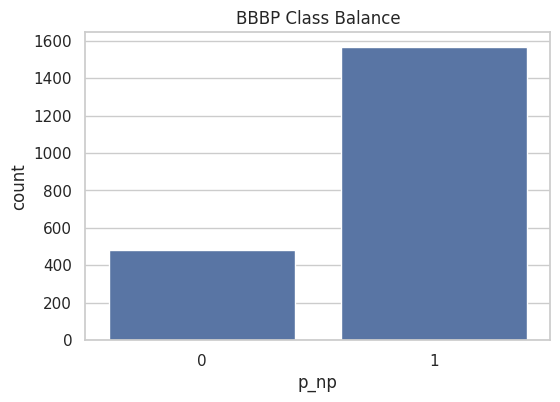

In [27]:
summary_stats = delaney[numeric_features + [target]].describe().T
display(summary_stats)

plt.figure(figsize=(8, 5))
sns.histplot(delaney[target], bins=30, kde=True)
plt.title("Distribution of Measured Log Solubility")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=bbbp, x="p_np")
plt.title("BBBP Class Balance")
plt.xlabel("p_np")
plt.show()

## Minimum Readiness Checklist

A learner is ready for the first model notebooks when they can:
- explain a weighted sum and threshold for binary classification
- interpret a feature matrix and a target vector
- describe a loss function and what a gradient means
- reason about class balance and train/test splits
- read PCA output and understand why dimensionality reduction may help